Num GPUs Available:  1
GPU is available, using GPU for training.
Found 27011 images belonging to 2 classes.
Found 4766 images belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 xception (Functional)       (None, 7, 7, 2048)        20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization_4 (Batc  (None, 256)              1024      
 hNormalization)                           

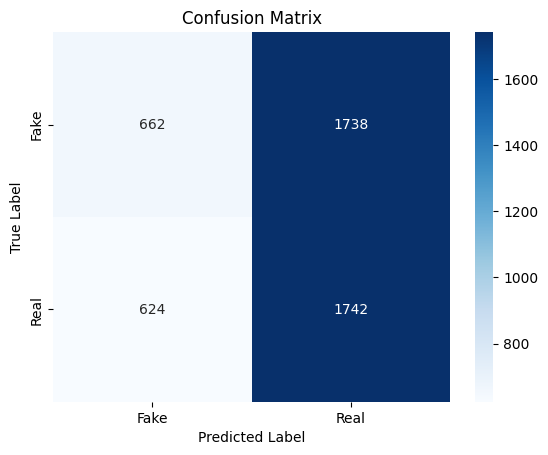

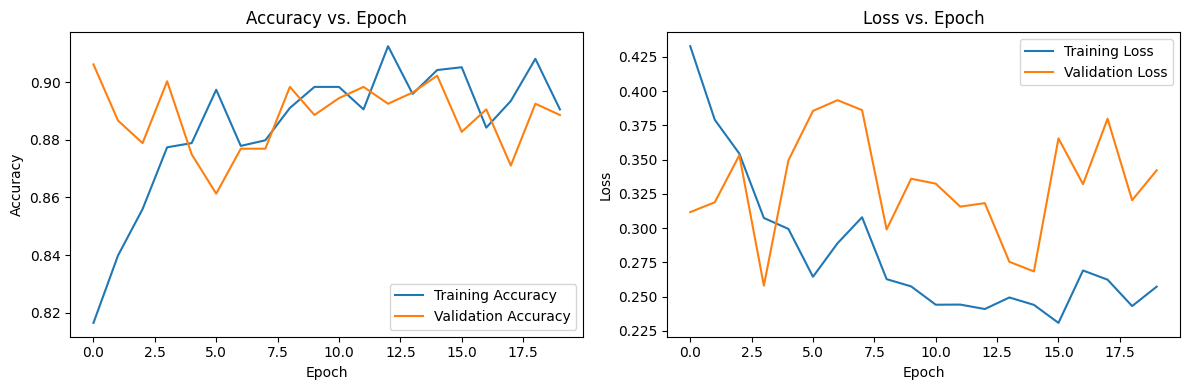

Found 8506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
532/532 [==============================] - 82s 152ms/step


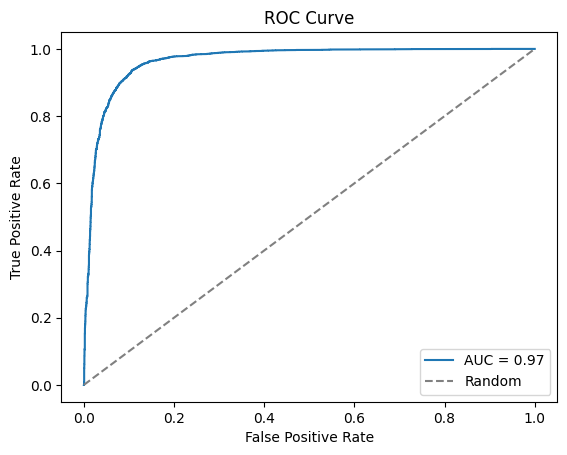

optimal threshold =  0.8755873
Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.89      0.91      4037
        Real       0.91      0.94      0.92      4469

    accuracy                           0.92      8506
   macro avg       0.92      0.91      0.92      8506
weighted avg       0.92      0.92      0.92      8506

Confusion Matrix:
[[3604  433]
 [ 285 4184]]


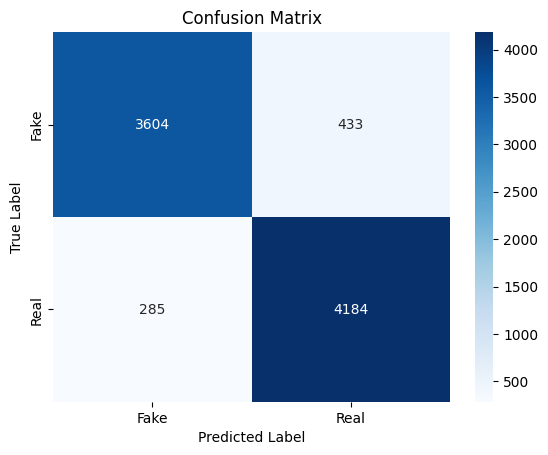

Evaluation Metrics:
accuracy: 0.9155889960028215
precision: 0.9267163795320134
recall: 0.8927421352489472
f1_score: 0.909412061569518
auc: 0.965838371434781


In [1]:
# --- Xception ---
import model_fit_evaluate 
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_input_xception
import tensorflow as tf
import os
import telebot

if __name__ == '__main__':

    data_dir = '../balanced_data/train'
    image_size = (224, 224)
    batch_size = 4 
    epochs = 20

    train_generator, validation_generator = model_fit_evaluate.create_data_generators(data_dir, image_size, batch_size, preprocessing_function=preprocess_input_xception)

    model = model_fit_evaluate.create_custom_model(
    base_model=Xception, 
    weights="imagenet",  
    input_shape=(224, 224, 3), 
    num_classes=1, 
    trainable_base=False 
    )

    # Train Model
    history = model_fit_evaluate.train_model(model, train_generator, validation_generator, epochs, batch_size, early_stopping_patience=6, reduce_lr_patience=4, reduce_lr_factor=0.2)

    # Evaluate Model
    model_fit_evaluate.evaluate_model(model, validation_generator)

    # Plot Training History
    model_fit_evaluate.plot_training_history(history)
    
    test_data_dir = '../balanced_data/test'

    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, test_data_dir, preprocess_input_xception, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics[0].items():
        print(f"{metric}: {value}")

Found 10110 images belonging to 2 classes.
632/632 [==============================] - 125s 198ms/step
[[1]
 [1]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Real       0.92      0.62      0.74      5089
        Fake       0.71      0.94      0.81      5021

    accuracy                           0.78     10110
   macro avg       0.81      0.78      0.78     10110
weighted avg       0.82      0.78      0.78     10110

Confusion Matrix:
[[3155 1934]
 [ 280 4741]]


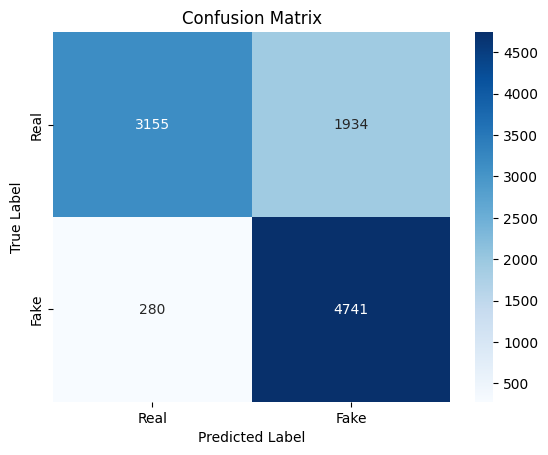

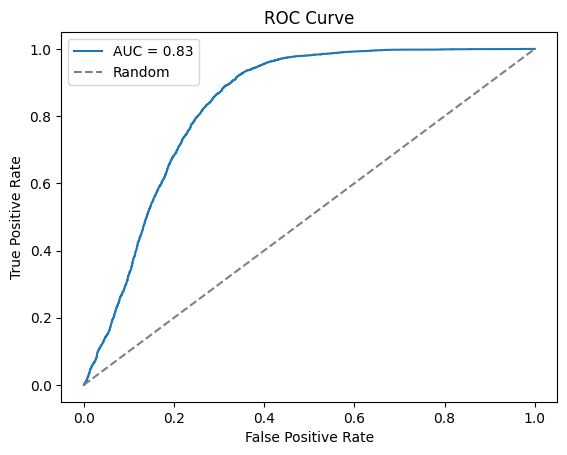

Evaluation Metrics:
accuracy: 0.7810089020771513
precision: 0.9184861717612809
recall: 0.6199646295932403
f1_score: 0.7402627874237447
auc: 0.8340157426448921


In [3]:
    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, '../OF/test', preprocess_input_xception, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

In [2]:
model.save('Xception_Deepfake.keras')